# Redes Mundo Pequeno

Vinicius Trindade Dias Abel - 2020007112

In [46]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import Counter
import numpy as np
import pandas as pd

## (a)

In [47]:
# Função para construir uma rede de mundo pequeno
def ConstroiRedeMundoPequeno(N, Z, p):
    """
    Constrói uma rede de mundo pequeno com N nós, Z conexões curtas por nó e probabilidade p de atalhos aleatórios.
    """
    G = nx.Graph()

    # Adiciona N nós
    G.add_nodes_from(range(N))

    # Adiciona arestas curtas
    for i in range(N):
        for j in range(1, Z // 2 + 1):
            G.add_edge(i, (i + j) % N)  # Conexão para frente
            G.add_edge(i, (i - j) % N)  # Conexão para trás

    # Adiciona atalhos aleatórios
    num_atalhos = int(p * N * Z / 2)
    for i in range(num_atalhos):
        u = np.random.randint(0,N)
        v = np.random.randint(0,N)
        G.add_edge(u, v)

    return G

## (b)

### (1)

In [48]:
# Função para encontrar os comprimentos de caminho a partir de um nó
def FindPathLengthsFromNode(graph, node):
    """
    Calcula as distâncias mais curtas de um nó para todos os outros no grafo usando NetworkX.
    """
    return nx.single_source_shortest_path_length(graph, node)

### (2)

In [49]:
# Função para encontrar todos os comprimentos de caminhos
def FindAllPathLengths(graph):
    """
    Calcula os comprimentos de caminho entre todos os pares de nós no grafo.
    """
    all_lengths = []
    for node in graph.nodes:
        distances = FindPathLengthsFromNode(graph, node)

        # Adiciona apenas os valores únicos (evita duplicatas no grafo não direcionado)
        all_lengths.extend(distances.values())

    return all_lengths

In [50]:
# Função para desenhar o grafo circular
def DesenhaGraficoCircular(graph, titulo="Gráfico Circular"):
    """
    Desenha o grafo em uma disposição circular.
    """
    plt.figure(figsize=(8, 8))
    nx.draw_circular(graph, with_labels=True, node_size=300, font_size=10)
    plt.title(titulo)
    plt.show()

In [51]:
# Função para gerar histograma de comprimentos de caminho
def GeraHistograma(comprimentos):
    """
    Gera um histograma a partir dos comprimentos de caminho entre nós.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(comprimentos, bins=range(1, max(comprimentos) + 2), edgecolor='black', alpha=0.7)
    plt.title("Histograma de Comprimentos de Caminho")
    plt.xlabel("Comprimento do Caminho")
    plt.ylabel("Frequência")
    plt.show()

#### Simulações

In [52]:
# Função para verificar se o histograma de p = 0 é constante
def VerificaHistogramaConstante(comprimentos, N, Z):
    """
    Verifica se o histograma é constante para o intervalo 0 < d < N/Z.
    """
    max_dist = N // Z  # Limite superior do intervalo
    frequencias = Counter(comprimentos)

    # Frequências no intervalo desejado
    interval_freq = [frequencias[d] for d in range(1, max_dist)]

    # Verifica se todas as frequências são iguais
    return len(set(interval_freq)) == 1


In [53]:
# Função para testar e analisar o comportamento da rede com diferentes valores de p
def TestaEAnalisa(N, Z, p):
    """
    Testa e analisa o comportamento de uma rede de mundo pequeno com diferentes valores de p.
    Gera gráficos circulares e histogramas de comprimentos de caminho.
    """
    grafo = ConstroiRedeMundoPequeno(N, Z, p)

    # Desenha gráfico circular
    DesenhaGraficoCircular(grafo)

    # Calcula comprimentos de caminho
    comprimentos = FindAllPathLengths(grafo)

    # Gera histograma
    GeraHistograma(comprimentos)

    # Verificar intervalo constante para p = 0
    if p == 0:
        constante = VerificaHistogramaConstante(comprimentos, N, Z)
        print(f"Para p = 0, histograma é constante para 0 < d < {N // Z}: {constante}")

    # Analisa média para "seis graus de separação"
    media_caminho = sum(comprimentos) / len(comprimentos)
    print(f"Média do comprimento do caminho para p = {p}: {media_caminho}")


In [54]:
# Parâmetros de teste
N, Z = 1000, 2

##### p = 0

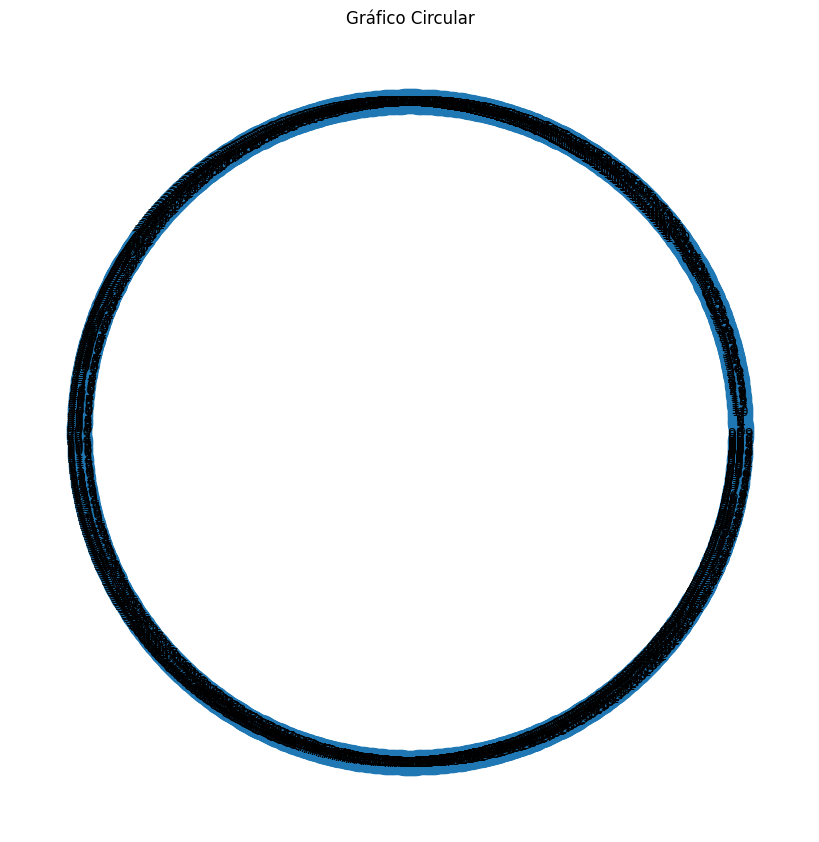

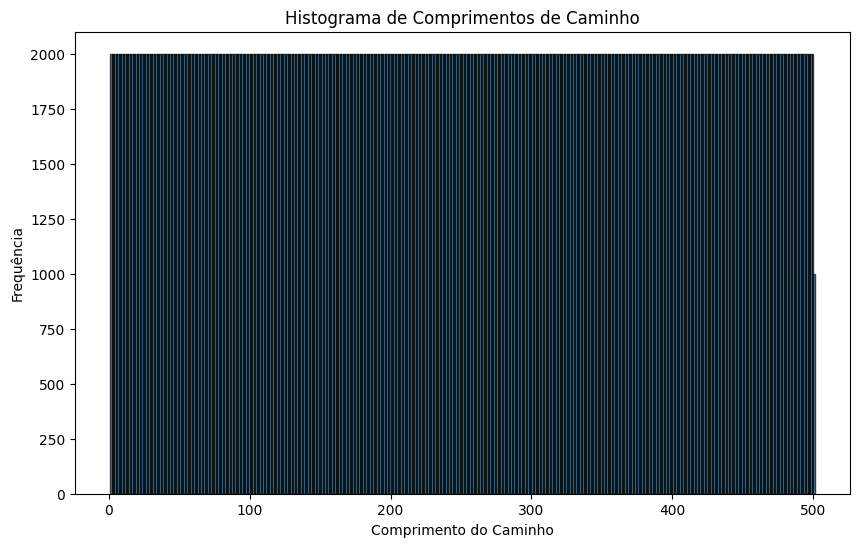

Para p = 0, histograma é constante para 0 < d < 500: True
Média do comprimento do caminho para p = 0: 250.0


In [55]:
p = 0
TestaEAnalisa(N, Z, p)

##### p = 0.02

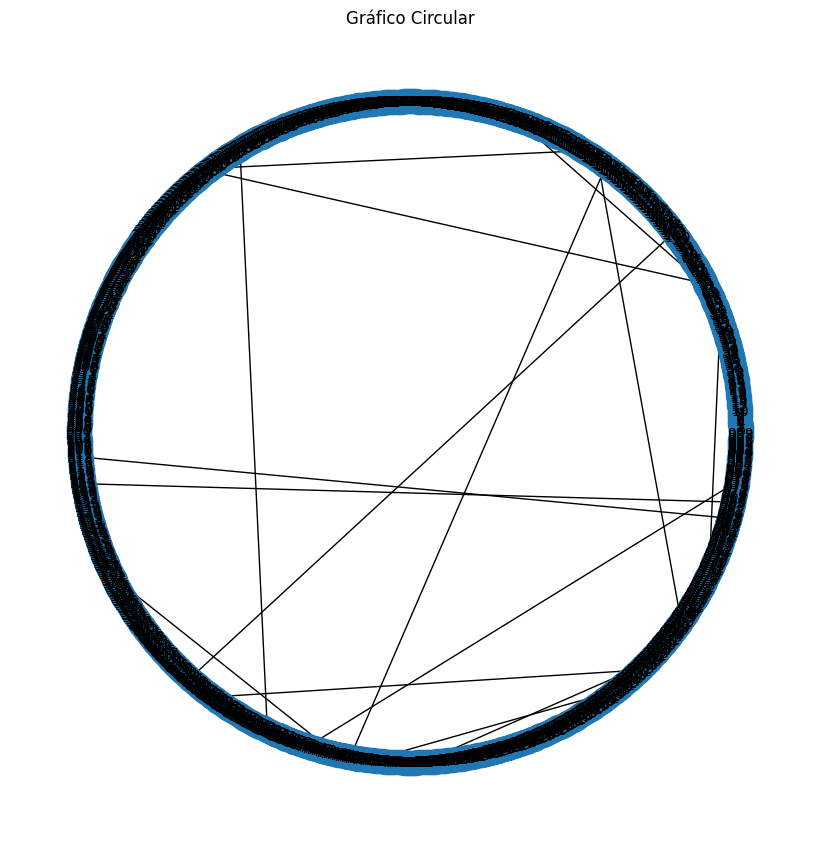

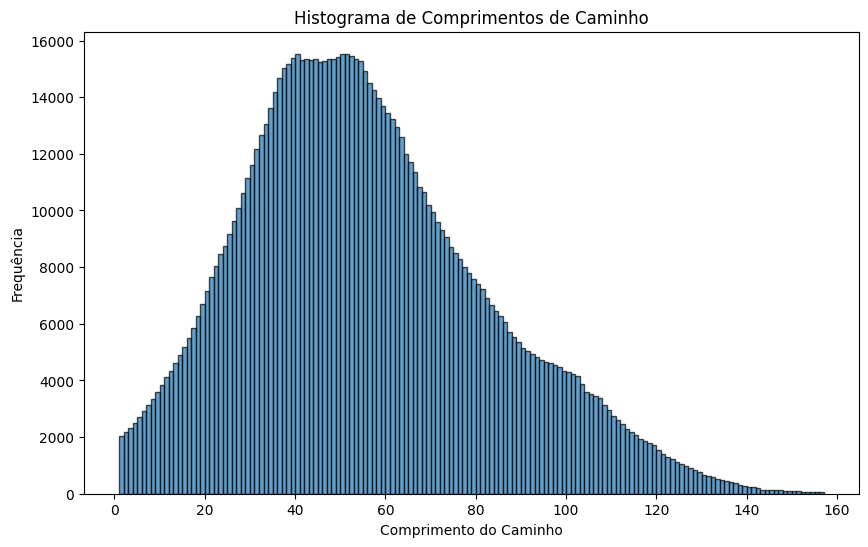

Média do comprimento do caminho para p = 0.02: 55.351654


In [56]:
p = 0.02
TestaEAnalisa(N, Z, p)

##### p = 0.2

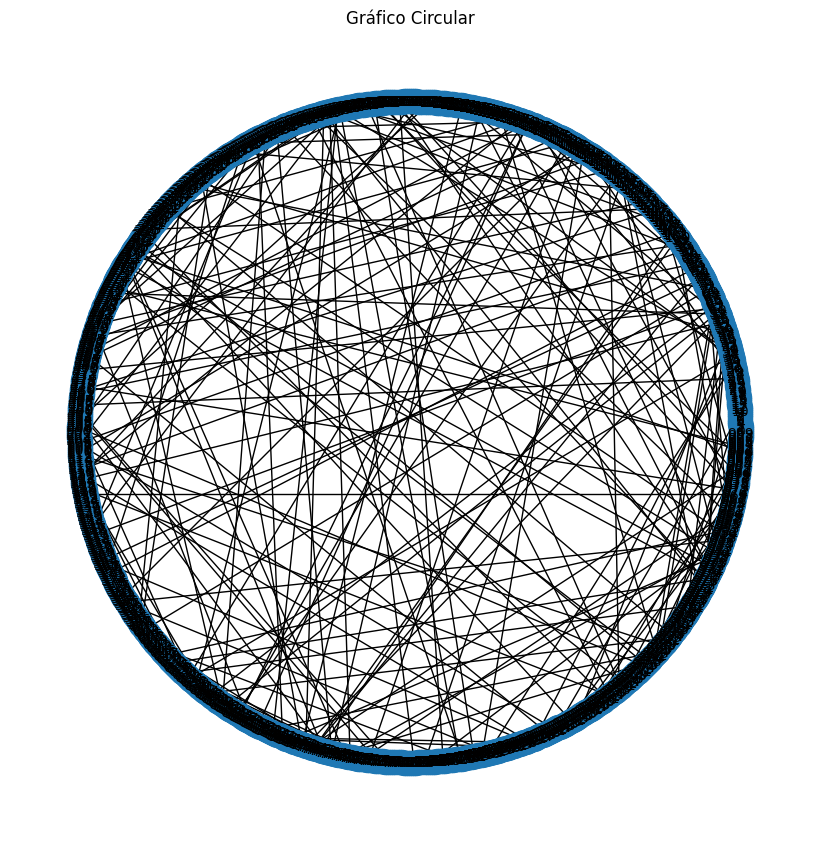

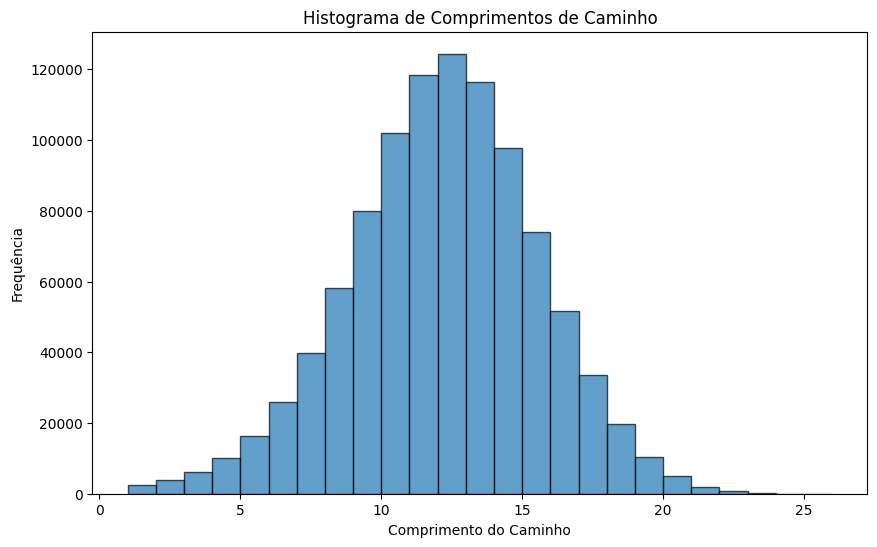

Média do comprimento do caminho para p = 0.2: 11.693366


In [57]:
p = 0.2
TestaEAnalisa(N, Z, p)

##### p = 0.75

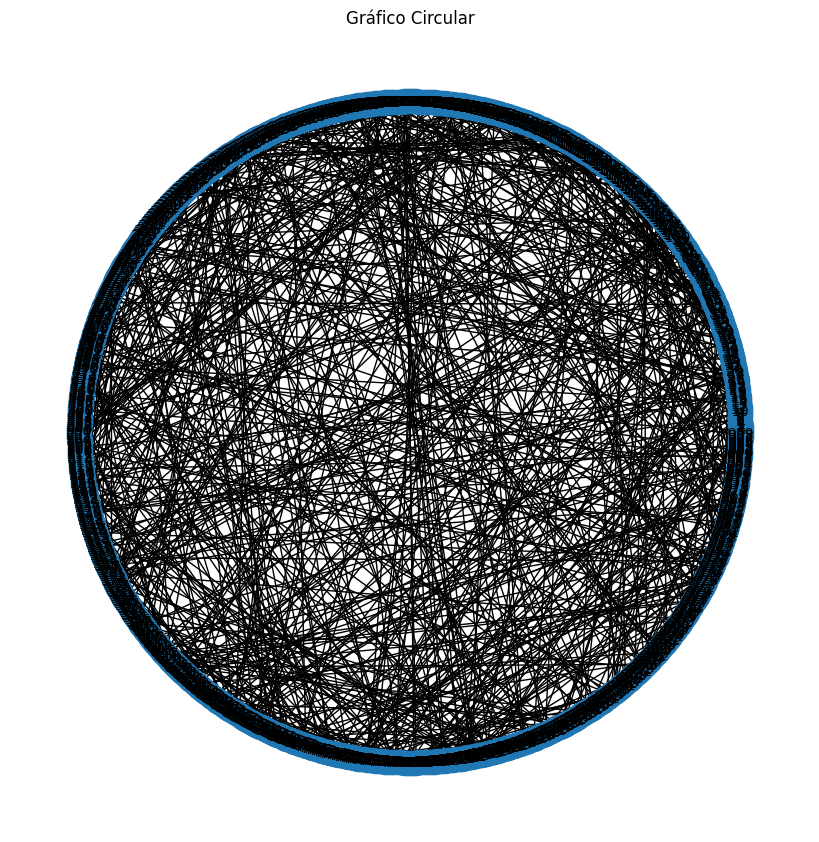

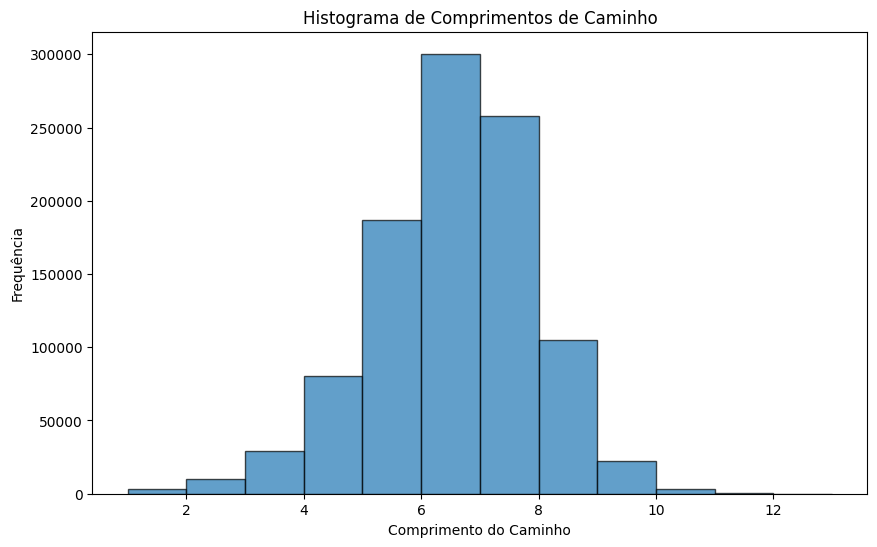

Média do comprimento do caminho para p = 0.75: 6.045492


In [58]:
p = 0.75
TestaEAnalisa(N, Z, p)

##### Análise de resultados

- Para \( p = 0 \):
  - O histograma dos comprimentos de caminho é uniforme no intervalo \( 0 < d < N/Z \).
  - Isso ocorre porque a rede é regular, sem atalhos. Todos os comprimentos de caminho estão igualmente distribuídos dentro desse intervalo.

- Para \( p > 0 \):
  - O histograma começa a perder sua uniformidade, concentrando-se em comprimentos menores.
  - Isso ocorre porque os atalhos encurtam os caminhos entre pares de nós, resultando em uma maior frequência de caminhos curtos.

- À medida que \( p \) aumenta:
  - A rede se torna altamente conectada devido à adição de muitos atalhos.
  - O histograma se concentra em comprimentos pequenos, indicando que a rede agora possui características de um mundo pequeno.

- Valor de \( p \) para "Seis Graus de Separação"
  - A análise dos resultados indica que, para \( p = 0.75 \), a média dos comprimentos de caminho \( d \) se aproxima de 6.
  - Isso significa que a probabilidade de \( p = 0.75 \) de criar atalhos é suficiente para transformar a rede em um sistema no qual qualquer par de nós está conectado por, em média, seis etapas.


### (3)

In [59]:
# Função para calcular a média dos comprimentos de caminho
def FindAveragePathLength(graph):
    """
    Calcula a média dos comprimentos de caminho entre todos os pares de nós no grafo.
    """
    # Calcula todos os comprimentos de caminho
    path_lengths = FindAllPathLengths(graph)

    # Retorna a média
    return sum(path_lengths) / len(path_lengths)

#### Simulações

In [60]:
# Função para realizar testes repetidos e observar flutuações
def RepeteTestes(N, Z, p, repeticoes):
    """
    Repete os testes para uma rede de mundo pequeno, observando flutuações no comprimento médio do caminho.
    """
    medias = []
    for _ in range(repeticoes):
        grafo = ConstroiRedeMundoPequeno(N, Z, p)
        media_caminho = FindAveragePathLength(grafo)
        medias.append(media_caminho)
    return medias

# Parâmetros de teste
N, Z, p = 100, 2, 0.1
repeticoes = 1000

# Repete os testes
medias = RepeteTestes(N, Z, p, repeticoes)

# Mostra os resultados
for i, media in enumerate(medias, 1):
    print(f"Tentativa {i}: Comprimento médio do caminho = {media}")

# Calcula estatísticas
media_global = sum(medias) / len(medias)
desvio_padrao = (sum((x - media_global) ** 2 for x in medias) / len(medias)) ** 0.5
print(f"Média global: {media_global}")
print(f"Desvio padrão: {desvio_padrao}")

# Número esperado de arestas longas
num_arestas_longas = p * N * Z / 2
print(f"Número esperado de arestas longas: {num_arestas_longas}")


Tentativa 1: Comprimento médio do caminho = 9.2546
Tentativa 2: Comprimento médio do caminho = 9.6408
Tentativa 3: Comprimento médio do caminho = 10.0254
Tentativa 4: Comprimento médio do caminho = 8.882
Tentativa 5: Comprimento médio do caminho = 9.8836
Tentativa 6: Comprimento médio do caminho = 16.8992
Tentativa 7: Comprimento médio do caminho = 9.7684
Tentativa 8: Comprimento médio do caminho = 9.288
Tentativa 9: Comprimento médio do caminho = 9.4068
Tentativa 10: Comprimento médio do caminho = 9.0848
Tentativa 11: Comprimento médio do caminho = 9.907
Tentativa 12: Comprimento médio do caminho = 9.0786
Tentativa 13: Comprimento médio do caminho = 10.3648
Tentativa 14: Comprimento médio do caminho = 9.1494
Tentativa 15: Comprimento médio do caminho = 8.5892
Tentativa 16: Comprimento médio do caminho = 9.0802
Tentativa 17: Comprimento médio do caminho = 8.7222
Tentativa 18: Comprimento médio do caminho = 9.7608
Tentativa 19: Comprimento médio do caminho = 9.5264
Tentativa 20: Comprim

O número esperado de arestas longas é dado pela fórmula:

p * N * Z / 2

Neste caso, p = 0.1, N = 100 e Z = 2, logo o número esperado de arestas longas é 10.

---

Flutuações nas distâncias eram esperadas porque as arestas longas foram criadas de forma aleatória.


## (c)

In [61]:
# Função para calcular o comprimento médio do caminho entre os nós d(p) dividido por d(p = 0)
def CalculaRazaoComprimentoMedio(N, Z, valores_p):
    """
    Calcula a razão d(p) / d(p=0) para uma rede de mundo pequeno.
    """
    # Calcula d(p=0)
    grafo_p0 = ConstroiRedeMundoPequeno(N, Z, p=0)
    d_p0 = FindAveragePathLength(grafo_p0)

    razoes = []  # Lista para armazenar as razões d(p) / d(p=0)

    for p in valores_p:
        grafo = ConstroiRedeMundoPequeno(N, Z, p)
        d_p = FindAveragePathLength(grafo)
        razoes.append(d_p / d_p0)
    return razoes

#### Simulação

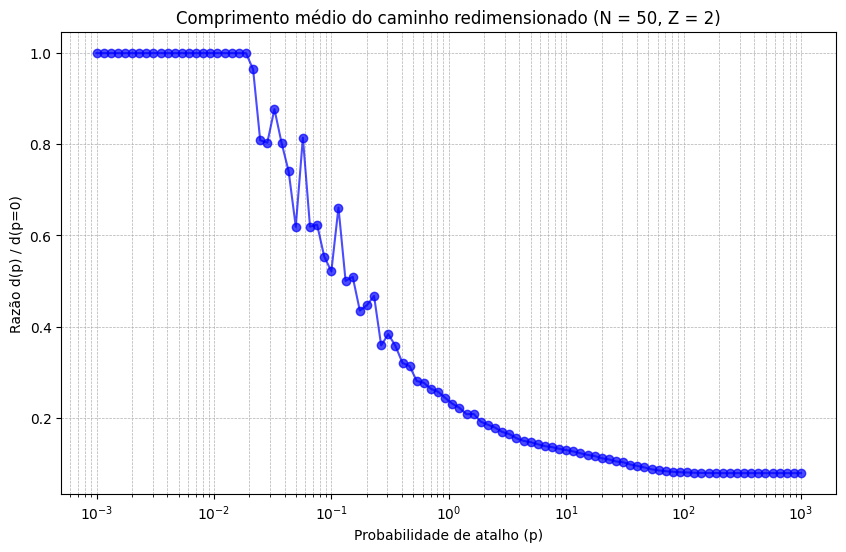

In [62]:
# Parâmetros
N = 50
Z = 2
valores_p = np.logspace(-3, 3, num=100)  # 100 valores logaritmicamente espaçados entre 10^-3 e 10^3

# Calcula as razões
razoes = CalculaRazaoComprimentoMedio(N, Z, valores_p)

# Plota o gráfico semi-log
plt.figure(figsize=(10, 6))
plt.semilogx(valores_p, razoes, marker='o', linestyle='-', color='b', alpha=0.7)
plt.xlabel("Probabilidade de atalho (p)")
plt.ylabel("Razão d(p) / d(p=0)")
plt.title("Comprimento médio do caminho redimensionado (N = 50, Z = 2)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

Para \( p \) pequeno, o gráfico é fixado em 1 porque a rede permanece praticamente regular, com poucas ou nenhuma conexão de atalho. Assim, os comprimentos de caminho são dominados pelas conexões locais, resultando em pouca variação na estrutura do grafo e no histograma.


## (d)

### Z=2, N=50, p=0.1

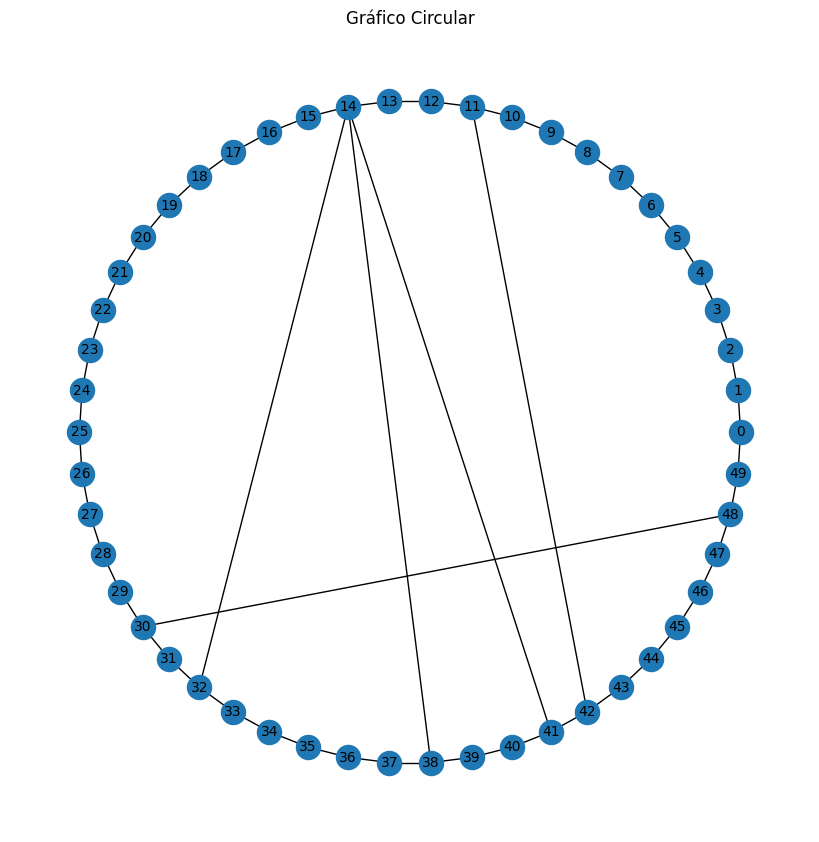

In [63]:
grafo = ConstroiRedeMundoPequeno(N=50, Z=2, p=0.1)
DesenhaGraficoCircular(grafo)

### Z=10, N=1000, p=0.1

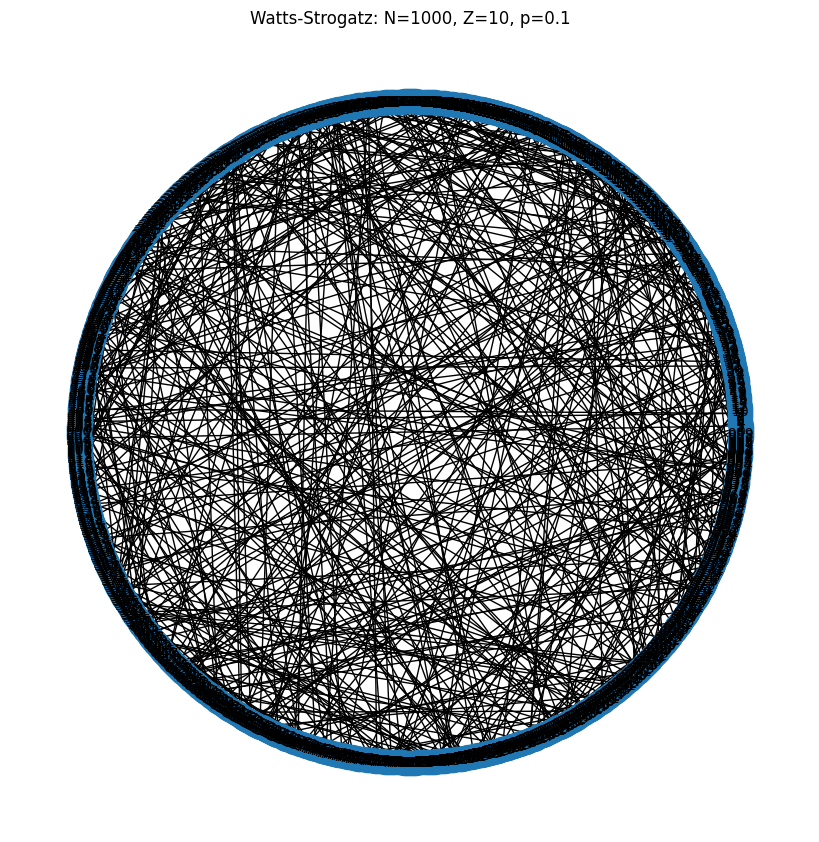

In [64]:
grafo = nx.watts_strogatz_graph(1000, 10, 0.1)
DesenhaGraficoCircular(grafo, f"Watts-Strogatz: N=1000, Z=10, p=0.1")

### Z=10, N=1000, p=0.001

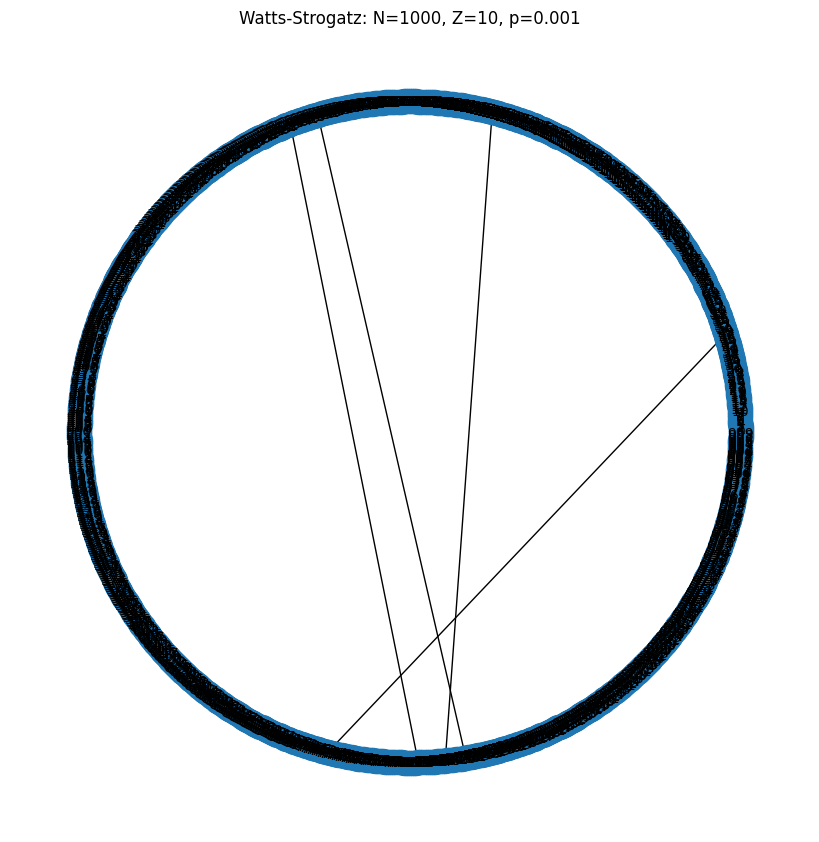

In [65]:
grafo = nx.watts_strogatz_graph(1000, 10, 0.001)
DesenhaGraficoCircular(grafo, f"Watts-Strogatz: N=1000, Z=10, p=0.001")

O gráfico de Watts e Strogatz com \( p = 0.001 \) se aproxima mais do meu sistema \( Z = 2, N = 50, p = 0.1 \), porque o número de arestas longas é semelhante.

### Comprimento médio do caminho redimensionado



In [66]:
# Função para calcular o comprimento médio redimensionado
def CalculaValoresRedimensionados(N_values, Z_values, p_values):
    """
    Calcula o comprimento médio redimensionado e o número total de atalhos
    para combinações de N, Z, e p.
    """
    resultados = {}

    for N in N_values:
        for Z in Z_values:
            atalhos = []
            d_redimensionados = []

            for p in p_values:
                grafo = ConstroiRedeMundoPequeno(N, Z, p)
                d = FindAveragePathLength(grafo)

                # Comprimento médio redimensionado
                d_redimensionado = (np.pi * Z * d) / N

                # Número total de atalhos
                atalhos_totais = p * N * Z / 2

                atalhos.append(atalhos_totais)
                d_redimensionados.append(d_redimensionado)

            resultados[(N, Z)] = (atalhos, d_redimensionados)

    return resultados

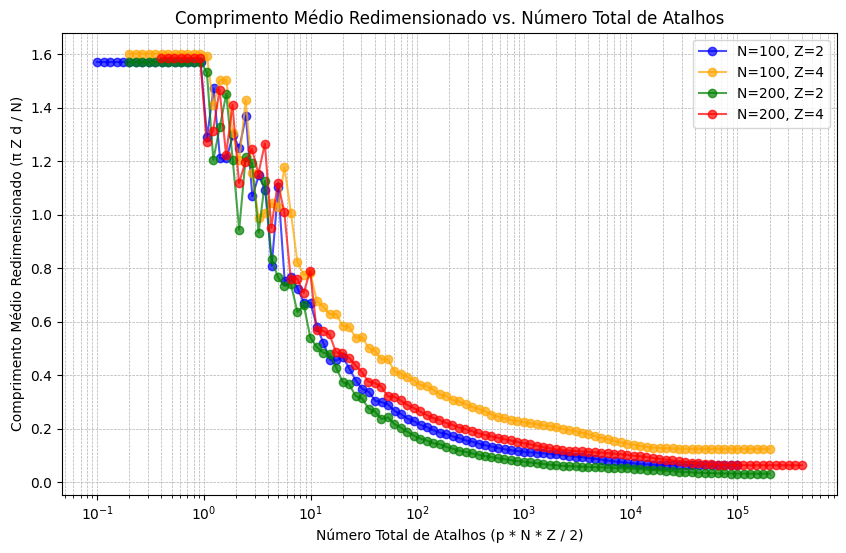

In [67]:
# Parâmetros
N_values = [100, 200]
Z_values = [2, 4]
p_values = np.logspace(-3, 3, num=100)  # Valores de p em escala logarítmica

# Calcula os valores
resultados = CalculaValoresRedimensionados(N_values, Z_values, p_values)

# Plota os resultados
plt.figure(figsize=(10, 6))

# Define cores para cada combinação de (N, Z)
cores = ['blue', 'orange', 'green', 'red']
for i, ((N, Z), (atalhos, d_redimensionados)) in enumerate(resultados.items()):
    plt.plot(atalhos, d_redimensionados, label=f'N={N}, Z={Z}', marker='o', color=cores[i], alpha=0.7)

plt.xscale('log')
plt.xlabel('Número Total de Atalhos (p * N * Z / 2)')
plt.ylabel('Comprimento Médio Redimensionado (π Z d / N)')
plt.title('Comprimento Médio Redimensionado vs. Número Total de Atalhos')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


## (e)

In [68]:
df = pd.read_csv('eco-mangwet.edges', sep=' ', header=None)
print(df.head())
print("\n")
print(f"Número de nós: {grafo.number_of_nodes()}")
print(f"Número de arestas: {grafo.number_of_edges()}")

    0  1      2
0  95  1  156.0
1  95  2  583.0
2  95  3  720.0
3  95  4   30.0
4  95  5   30.0


Número de nós: 1000
Número de arestas: 5000


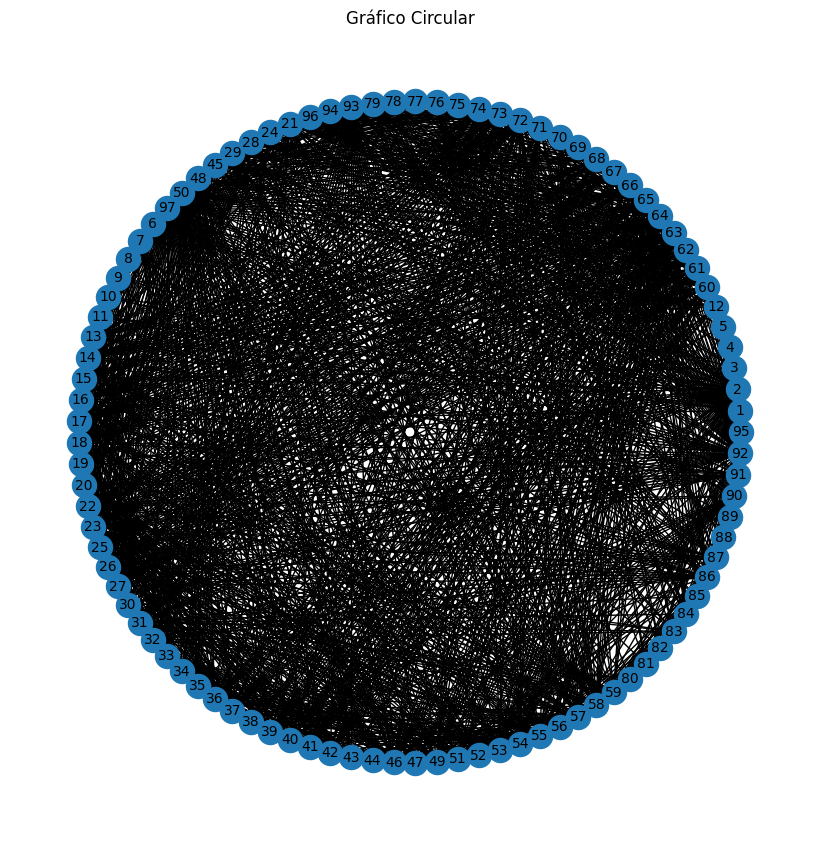

In [69]:
grafo = nx.from_pandas_edgelist(df, source=0, target=1, edge_attr=2)
DesenhaGraficoCircular(grafo)

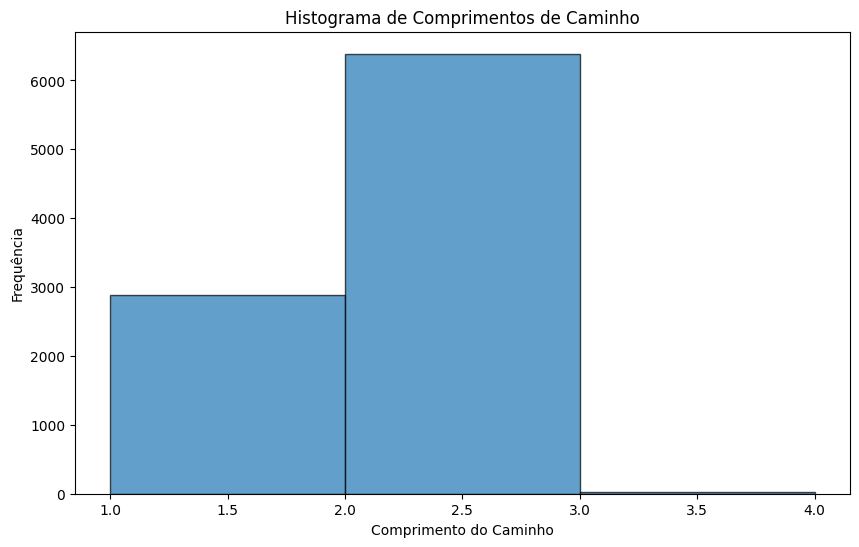

In [70]:
comprimentos = FindAllPathLengths(grafo)
GeraHistograma(comprimentos)

In [71]:
media_caminho = FindAveragePathLength(grafo)
print('O comprimento médio dos caminhos é: ', media_caminho)

O comprimento médio dos caminhos é:  1.6754171537889255
